# Import modules

In [1]:
import timm
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
import os
import glob
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import torch.nn.functional as F
import wandb
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import pandas as pd

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("wandb_classifier")

check = wandb.login(secret_value_0)

if check:
    print('wandb login succsssful!')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nobonobonobok (nobonobonobok-university-of-cambridge) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb login succsssful!


In [3]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

print(device)

cuda


# Data loading

In [4]:
#loading data
train_data_dir="/kaggle/input/datasets/kogennobori/oct-original-dataset-v3/combined3_split_rgb_jpeg/train"

test_data_dir="/kaggle/input/datasets/kogennobori/oct-original-dataset-v3/combined3_split_rgb_jpeg/test"
#Reference: https://stackoverflow.com/questions/10439104/reading-bmp-files-in-python

In [5]:
# set image size here
img_size=224

#Reference: https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
train_transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
])

tv_transform = transforms.Compose([
    transforms.Resize((img_size,img_size)),
    transforms.ToTensor(),
])
#Reference: https://stackoverflow.com/questions/69199273/torchvision-imagefolder-could-not-find-any-class-folder

train_data=datasets.ImageFolder(train_data_dir, transform=train_transform)
test_data=datasets.ImageFolder(test_data_dir,transform=tv_transform)


train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# Model setup

In [6]:
model = timm.create_model('swin_tiny_patch4_window7_224.ms_in1k', pretrained=True, num_classes = 10)
model.to(device)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

# Training

In [7]:
# set hyperparameters
epochs = 10
lr = 0.01
momentum = 0.9

In [8]:
# set loss function and optimisation method
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

In [9]:
# wandb setting.
# Project that the run is recorded to
project = "classifier"


config = {
    'epochs' : epochs,
    'lr' : lr,
    'momentum' : momentum,
    'dataset_folder': train_data_dir
}

In [10]:
# training loop
with wandb.init(project=project, config=config) as run:
    for epoch in range(epochs):
        print(f"Training epoch {epoch}...")
    
        running_loss =0.0
        #Reference: https://zenn.dev/zzz/articles/970e5df5cf1f65
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
        
            optimizer.zero_grad()
        
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
            running_loss += loss.item()

            loss = round((running_loss / len(train_loader)),4)
            
        print((f'Loss:{loss}'))
        run.log({"loss": loss})
      
    
    print("finished Training!")

    # Save the model
    torch.save(model.state_dict(), 'trained_net.pth')
    
    artifact = wandb.Artifact('classifier', type='model')

    #Specify the path to the model checkpoint file that you want to upload
    artifact.add_file('trained_net.pth') 
    
    run.log_artifact(artifact)

wandb: setting up run ozl1g5ns
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260827_201040-ozl1g5ns
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run fluent-snowball-9
wandb: ⭐️ View project at https://wandb.ai/nobonobonobok-university-of-cambridge/classifier
wandb: 🚀 View run at https://wandb.ai/nobonobonobok-university-of-cambridge/classifier/runs/ozl1g5ns


Training epoch 0...
Loss:1.3626
Training epoch 1...
Loss:1.353
Training epoch 2...
Loss:1.3463
Training epoch 3...
Loss:0.6134
Training epoch 4...
Loss:0.1827
Training epoch 5...
Loss:0.1324
Training epoch 6...
Loss:0.1073
Training epoch 7...
Loss:0.0858
Training epoch 8...
Loss:0.0728
Training epoch 9...
Loss:0.0615
finished Training!


wandb: uploading artifact classifier; updating run metadata
wandb: uploading artifact classifier
wandb: uploading artifact classifier; uploading history steps 9-9, summary, console lines 19-20
wandb: uploading artifact classifier
wandb: uploading artifact classifier; uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading artifact classifier; uploading output.log; uploading config.yaml
wandb: uploading artifact classifier
wandb: 
wandb: Run history:
wandb: loss ███▄▂▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb: loss 0.0615
wandb: 
wandb: 🚀 View run fluent-snowball-9 at: https://wandb.ai/nobonobonobok-university-of-cambridge/classifier/runs/ozl1g5ns
wandb: ⭐️ View project at: https://wandb.ai/nobonobonobok-university-of-cambridge/classifier
wandb: Synced 5 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260827_201040-ozl1g5ns/logs


In [11]:
# script for saving the model in case you stopped training loop before it saves a model.

# torch.save(model.state_dict(), 'trained_net.pth')

# #Specify the project name and run ID found in Run path. (username/project_name/run_id)
# run = wandb.init(project='classifier', id='8x7y6a6i', resume='allow')
# artifact = wandb.Artifact('classifier', type='model', description="test: resnet34, original OCT dataset, interrupted during epoch 3, achieved accuracy 95.8%")

# #Specify the path to the model checkpoint file that you want to upload
# artifact.add_file('trained_net.pth') 

# run.log_artifact(artifact)
# run.finish()

# Testing

In [12]:
# Loading the model. Not necessary if you already have.
# model = timm.create_model(, pretrained=True, num_classes = 10)
# model.to(device)
# model.load_state_dict(torch.load(""))
model.eval() # is this necessary?

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [13]:
print(test_data.class_to_idx)

{'AMD': 0, 'CNV': 1, 'CSR': 2, 'DME': 3, 'DRUSEN': 4, 'ERM': 5, 'NORMAL': 6, 'RAO': 7, 'RVO': 8, 'VID': 9}


In [14]:
# https://stackoverflow.com/questions/68047990/pytorch-imagefolder-which-index-does-a-folder-get
classes = ('AMD','CNV', 'CSR', 'DME', 'DRUSEN', 'ERM', 'NORMAL', 'RAO', 'RVO', 'VID' )

## Calculation of accuracy

In [15]:
correct = 0
total = 0

with torch.no_grad():
  for data in test_loader:
    images,labels = data[0].to(device), data[1].to(device)
    outputs=model(images)
    _, predicted = torch.max(outputs,1)
    total+=labels.size(0)
    correct+=(predicted == labels).sum().item()

accuracy = round(100*correct/total,2)

print(f"Accuracy of the model is: {accuracy}%")

Accuracy of the model is: 96.39%


## Visualisation

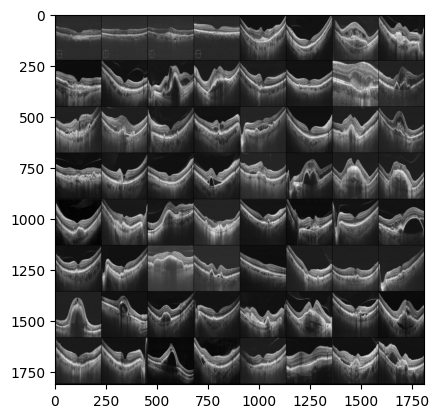

GroundTruth:  AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD  
Predicted:  AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   NORMAL AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   NORMAL AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   AMD   ERM   AMD   AMD   AMD   AMD   AMD   AMD  


In [16]:
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
# https://stackoverflow.com/questions/59013109/runtimeerror-input-type-torch-floattensor-and-weight-type-torch-cuda-floatte
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(test_loader)
images, labels = next(dataiter)[0].to(device), next(dataiter)[1].to(device)


# print images
imshow(torchvision.utils.make_grid(images).cpu())
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(64)))

outputs = model(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(64)))

## Confusion matrix

In [17]:
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: AMD   is 96.9 %
Accuracy for class: CNV   is 97.8 %
Accuracy for class: CSR   is 90.9 %
Accuracy for class: DME   is 92.4 %
Accuracy for class: DRUSEN is 86.3 %
Accuracy for class: ERM   is 87.5 %
Accuracy for class: NORMAL is 98.1 %
Accuracy for class: RAO   is 66.7 %
Accuracy for class: RVO   is 72.7 %
Accuracy for class: VID   is 96.2 %


In [18]:
true = []
pred = []

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels.cpu(), predictions.cpu()):
            true.append(label)
            pred.append(prediction)

            
cm = confusion_matrix(true, pred)

# print(cm)



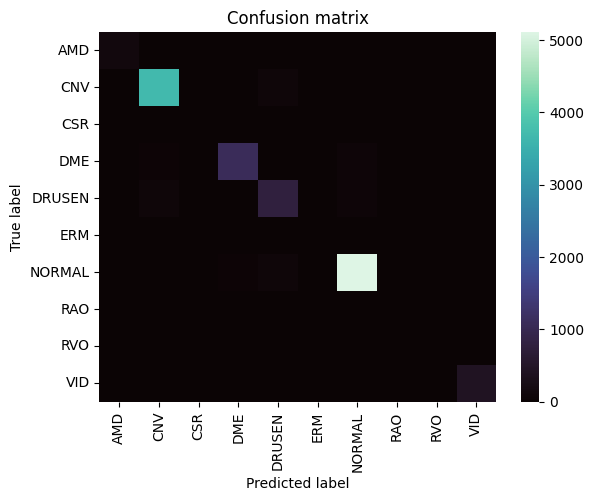

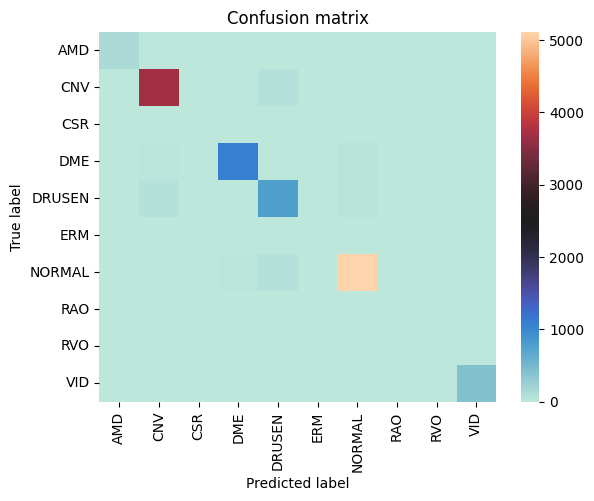

In [19]:
df_cm = pd.DataFrame(cm, columns = classes, index = classes)
# df_cm = pd.DataFrame(cm)

sns.heatmap(df_cm, cmap='mako')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix')
plt.show()

# diverging color palette
sns.heatmap(df_cm, cmap='icefire')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix')
plt.show()

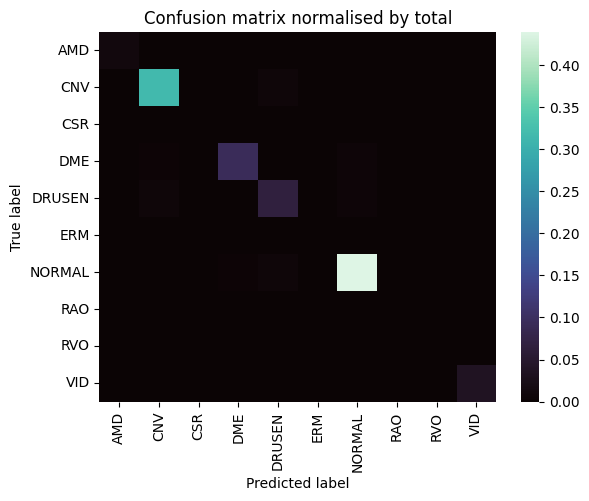

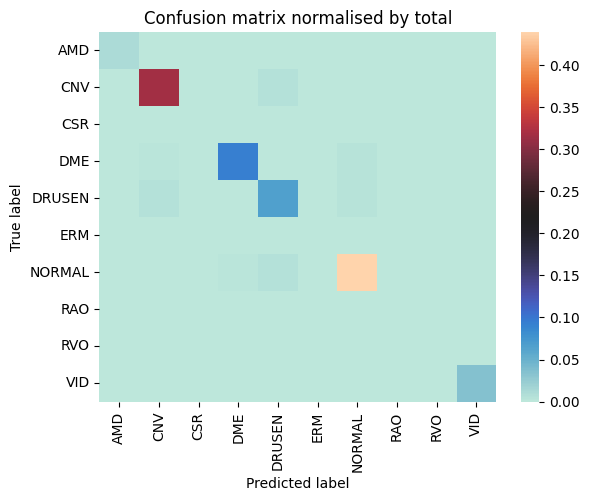

In [20]:
# normalised confusion matrix
total_n = len(true)

df_cm_norm = df_cm/total_n

sns.heatmap(df_cm_norm, cmap='mako')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix normalised by total')
plt.show()

sns.heatmap(df_cm_norm, cmap='icefire')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix normalised by total')
plt.show()

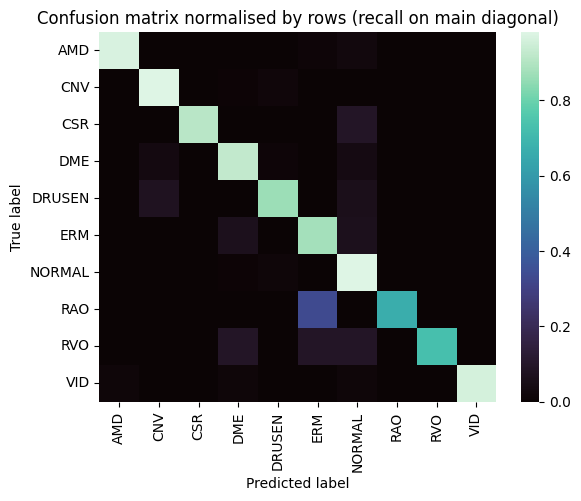

In [21]:
# https://stackoverflow.com/questions/35678874/normalize-rows-of-pandas-data-frame-by-their-sums
sums_row = np.sum(cm, axis=1)
# Source - https://stackoverflow.com/a/35679163
# Posted by Ami Tavory
# Retrieved 2026-08-25, License - CC BY-SA 3.0

df_cm_norm_rows = df_cm.div(sums_row, axis=0)

sns.heatmap(df_cm_norm_rows, cmap='mako')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix normalised by rows (recall on main diagonal)')
plt.show()

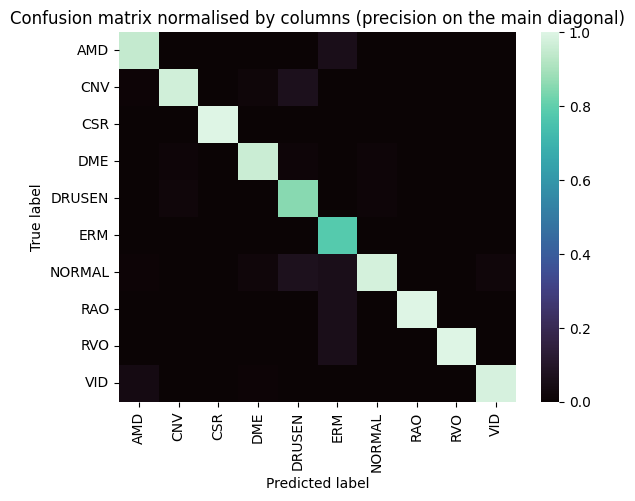

In [22]:
# https://stackoverflow.com/questions/35678874/normalize-rows-of-pandas-data-frame-by-their-sums
sums_row = np.sum(cm, axis=0)


df_cm_norm_rows = df_cm.div(sums_row, axis=1)

sns.heatmap(df_cm_norm_rows, cmap='mako')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix normalised by columns (precision on the main diagonal)')
plt.show()

In [23]:
# matrix summary
print(classification_report(true, pred, target_names=classes))

              precision    recall  f1-score   support

         AMD       0.95      0.97      0.96       130
         CNV       0.97      0.98      0.97      3756
         CSR       1.00      0.91      0.95        11
         DME       0.96      0.92      0.94      1185
      DRUSEN       0.85      0.86      0.86       901
         ERM       0.78      0.88      0.82        16
      NORMAL       0.98      0.98      0.98      5207
         RAO       1.00      0.67      0.80         3
         RVO       1.00      0.73      0.84        11
         VID       0.98      0.96      0.97       418

    accuracy                           0.96     11638
   macro avg       0.95      0.89      0.91     11638
weighted avg       0.96      0.96      0.96     11638



## Breakdown of predicted as NORMAL

In [24]:
# classes as a list
classes = ['AMD','CNV', 'CSR', 'DME', 'DRUSEN', 'ERM', 'NORMAL', 'RAO', 'RVO', 'VID' ]

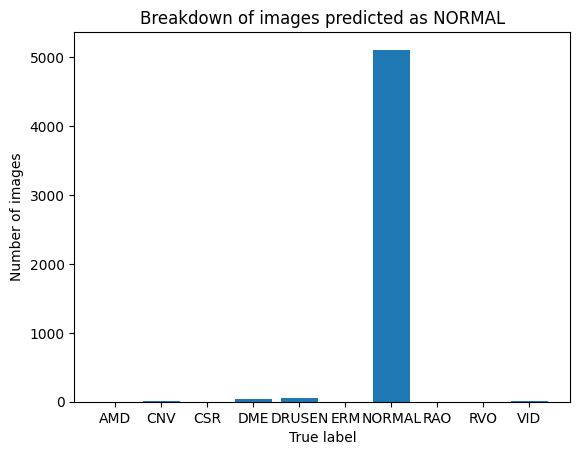

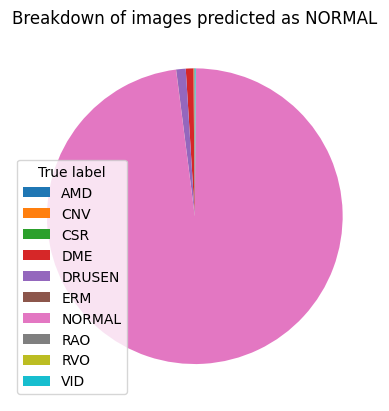

Total number of images predicted as NORMAL: 5221


Breakdown of the true labels:
AMD 0.06 %
CNV 0.08 %
CSR 0.02 %
DME 0.82 %
DRUSEN 1.03 %
ERM 0.02 %
NORMAL 97.85 %
RAO 0.0 %
RVO 0.02 %
VID 0.1 %


In [25]:
bd_normal = cm[:,6]
tot_normal = bd_normal.sum()

plt.bar(classes, bd_normal)
plt.title('Breakdown of images predicted as NORMAL')
plt.xlabel('True label')
plt.ylabel('Number of images')
plt.show()

plt.pie(bd_normal, labels=classes, startangle=90, labeldistance=None)
plt.title('Breakdown of images predicted as NORMAL')
plt.legend(title = 'True label')
plt.show()

print('Total number of images predicted as NORMAL:', tot_normal)
print('\n')
print('Breakdown of the true labels:')
for i in range(len(classes)):
    print(classes[i], round(bd_normal[i]/tot_normal*100, 2),'%')

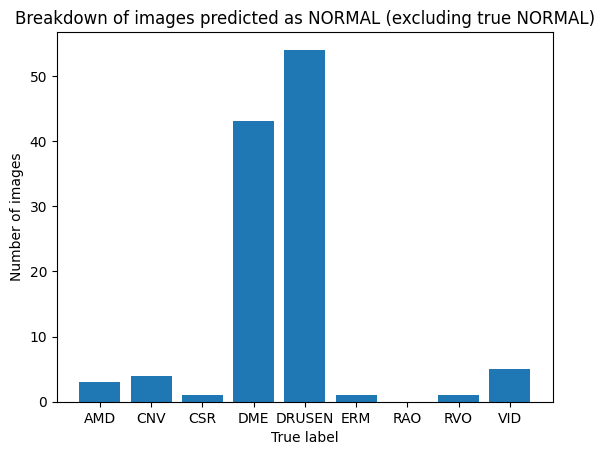

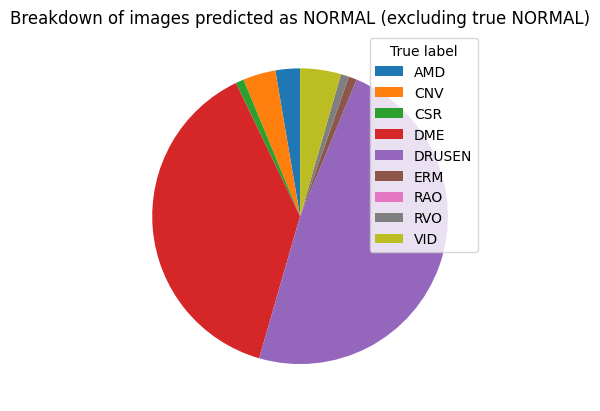

Total number of images predicted as NORMAL (excluding true NORMAL): 112


Breakdown of the true labels (excluding true NORMAL):
AMD 2.68 %
CNV 3.57 %
CSR 0.89 %
DME 38.39 %
DRUSEN 48.21 %
ERM 0.89 %
RAO 0.0 %
RVO 0.89 %
VID 4.46 %


In [26]:
bd_normal_wout_n = np.delete(cm[:,6],6)
tot_normal_wout_n = bd_normal_wout_n.sum()

classes = ['AMD','CNV', 'CSR', 'DME', 'DRUSEN', 'ERM', 'NORMAL', 'RAO', 'RVO', 'VID' ]
classes.pop(6)
# print(bd_normal_wout_n, classes)

plt.bar(classes, bd_normal_wout_n)
plt.title('Breakdown of images predicted as NORMAL (excluding true NORMAL)')
plt.xlabel('True label')
plt.ylabel('Number of images')
plt.show()

plt.pie(bd_normal_wout_n, labels=classes, startangle=90, labeldistance=None)
plt.title('Breakdown of images predicted as NORMAL (excluding true NORMAL)')
plt.legend(title = 'True label')
plt.show()

print('Total number of images predicted as NORMAL (excluding true NORMAL):', tot_normal_wout_n)
print('\n')
print('Breakdown of the true labels (excluding true NORMAL):')
for i in range(len(classes)):
    print(classes[i], round(bd_normal_wout_n[i]/tot_normal_wout_n*100, 2),'%')

## Saving images predicted as NORMAL

In [27]:
classes = ['AMD','CNV', 'CSR', 'DME', 'DRUSEN', 'ERM', 'NORMAL', 'RAO', 'RVO', 'VID' ]

In [28]:
out_dir = 'combined3_split_rgb_jpeg_predicted_NORMAL_transformer_run_all'

In [29]:
!mkdir {out_dir}
for i in classes:
    !mkdir {out_dir}/{i}

In [30]:
c = 0
tot_c = 0
norm_c = 0

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for image, label, prediction in zip(images, labels, predictions):
            tot_c+=1
            # NORMAL..6
            # judging if the image was predicted to be NORMAL
            if prediction == 6:
                norm_c+=1
                # judging if the image is not actually NORMAL
                if label !=6:
                    c+=1
                    # image = image.cpu()
                    # imshow(image) #for visualisation. imshow is a function defined previously. This is needed as PyTorch tensor has different order of channels from the one plt accepts
                    # print('^ prediction:', classes[prediction], 'true:', classes[label])
                    # print('{}/{}/{}.jpeg'.format(out_dir, classes[label],c))
                    # saving the image
                    save_image(image, '{}/{}/{}.jpeg'.format(out_dir, classes[label],c))

print('Total number of images:', tot_c)
print('Number of images predicted as NORMAL:', norm_c)
print('Number of images falsely predicted as NORMAL:', c)
                

Total number of images: 11638
Number of images predicted as NORMAL: 5221
Number of images falsely predicted as NORMAL: 112


## Saving images predicted DME & true DME as an example

In [31]:
out_dir_ex1 = 'combined3_split_rgb_jpeg_pred_DME_true_DME_transformer_run_all'
!mkdir {out_dir_ex1}

In [32]:
c = 0
tot_c = 0
dme_c = 0

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for image, label, prediction in zip(images, labels, predictions):
            tot_c+=1
            # DME..3
            # judging if the image was predicted to be DME
            if prediction == 3:
                dme_c+=1
                # judging if the image is actually DME
                if label == 3:
                    c+=1
                    # image = image.cpu()
                    # imshow(image) #for visualisation. imshow is a function defined previously. This is needed as PyTorch tensor has different order of channels from the one plt accepts
                    # print('^ prediction:', classes[prediction], 'true:', classes[label])
                    # print('{}/{}/{}.jpeg'.format(out_dir, classes[label],c))
                    # saving the image
                    save_image(image, '{}/{}.jpeg'.format(out_dir_ex1,c))

print('Total number of images:', tot_c)
print('Number of images predicted as DME:', dme_c)
print('Number of images for true DME:', c)


Total number of images: 11638
Number of images predicted as DME: 1143
Number of images for true DME: 1095
